In [27]:
import polars as pl

# 데이터 로드
df = pl.read_parquet('../data/processed/train_final.parquet') # 또는 저장된 파일명

# 컬럼 이름 중에 'addr_state'가 포함된 것 찾기
state_cols = [c for c in df.columns if 'addr_state' in c]
purpose_cols = [c for c in df.columns if 'purpose' in c]

print(f"대출목적 관련 변수 개수: {len(purpose_cols)}개")
print(f"전체 변수 개수: {len(df.columns)}개")

대출목적 관련 변수 개수: 14개
전체 변수 개수: 105개


In [28]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

# 1. 폰트 및 스타일 설정 (에러 방지용 기본 폰트)
plt.rcParams['font.family'] = 'sans-serif' 
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

# 2. 데이터 로드
file_path = '../data/processed/train_final.parquet'
df = pl.read_parquet(file_path)

print(f"전체 데이터 Shape: {df.shape}")

# 3. 시각화용 샘플링 (5만 개)
# 전체 데이터를 다 그리면 느리고 메모리가 터집니다.
n_sample = 50000
df_pd = df.sample(n=n_sample, seed=42).to_pandas()

print(f"시각화용 샘플링 완료: {df_pd.shape}")

전체 데이터 Shape: (1125996, 105)
시각화용 샘플링 완료: (50000, 105)


📊 1. [Overview] 범주형/연속형 분리 배치 시각화
변수가 105개나 되므로, 한 번에 16개씩 페이지를 넘겨가며 보는 것이 좋습니다. 이미 모든 변수가 숫자(수치)로 되어 있지만, **"고유값 개수"**를 기준으로 범주형(이산형)과 연속형을 나누어 그립니다.

범주형(Categorical): 막대그래프 (Countplot)

연속형(Numerical): 히스토그램 (Histplot)

📊 범주형/이산형 변수: 46개
📈 연속형/수치형 변수: 58개

🚀 [CATEGORICAL] 변수 시각화 시작 (총 3 페이지)


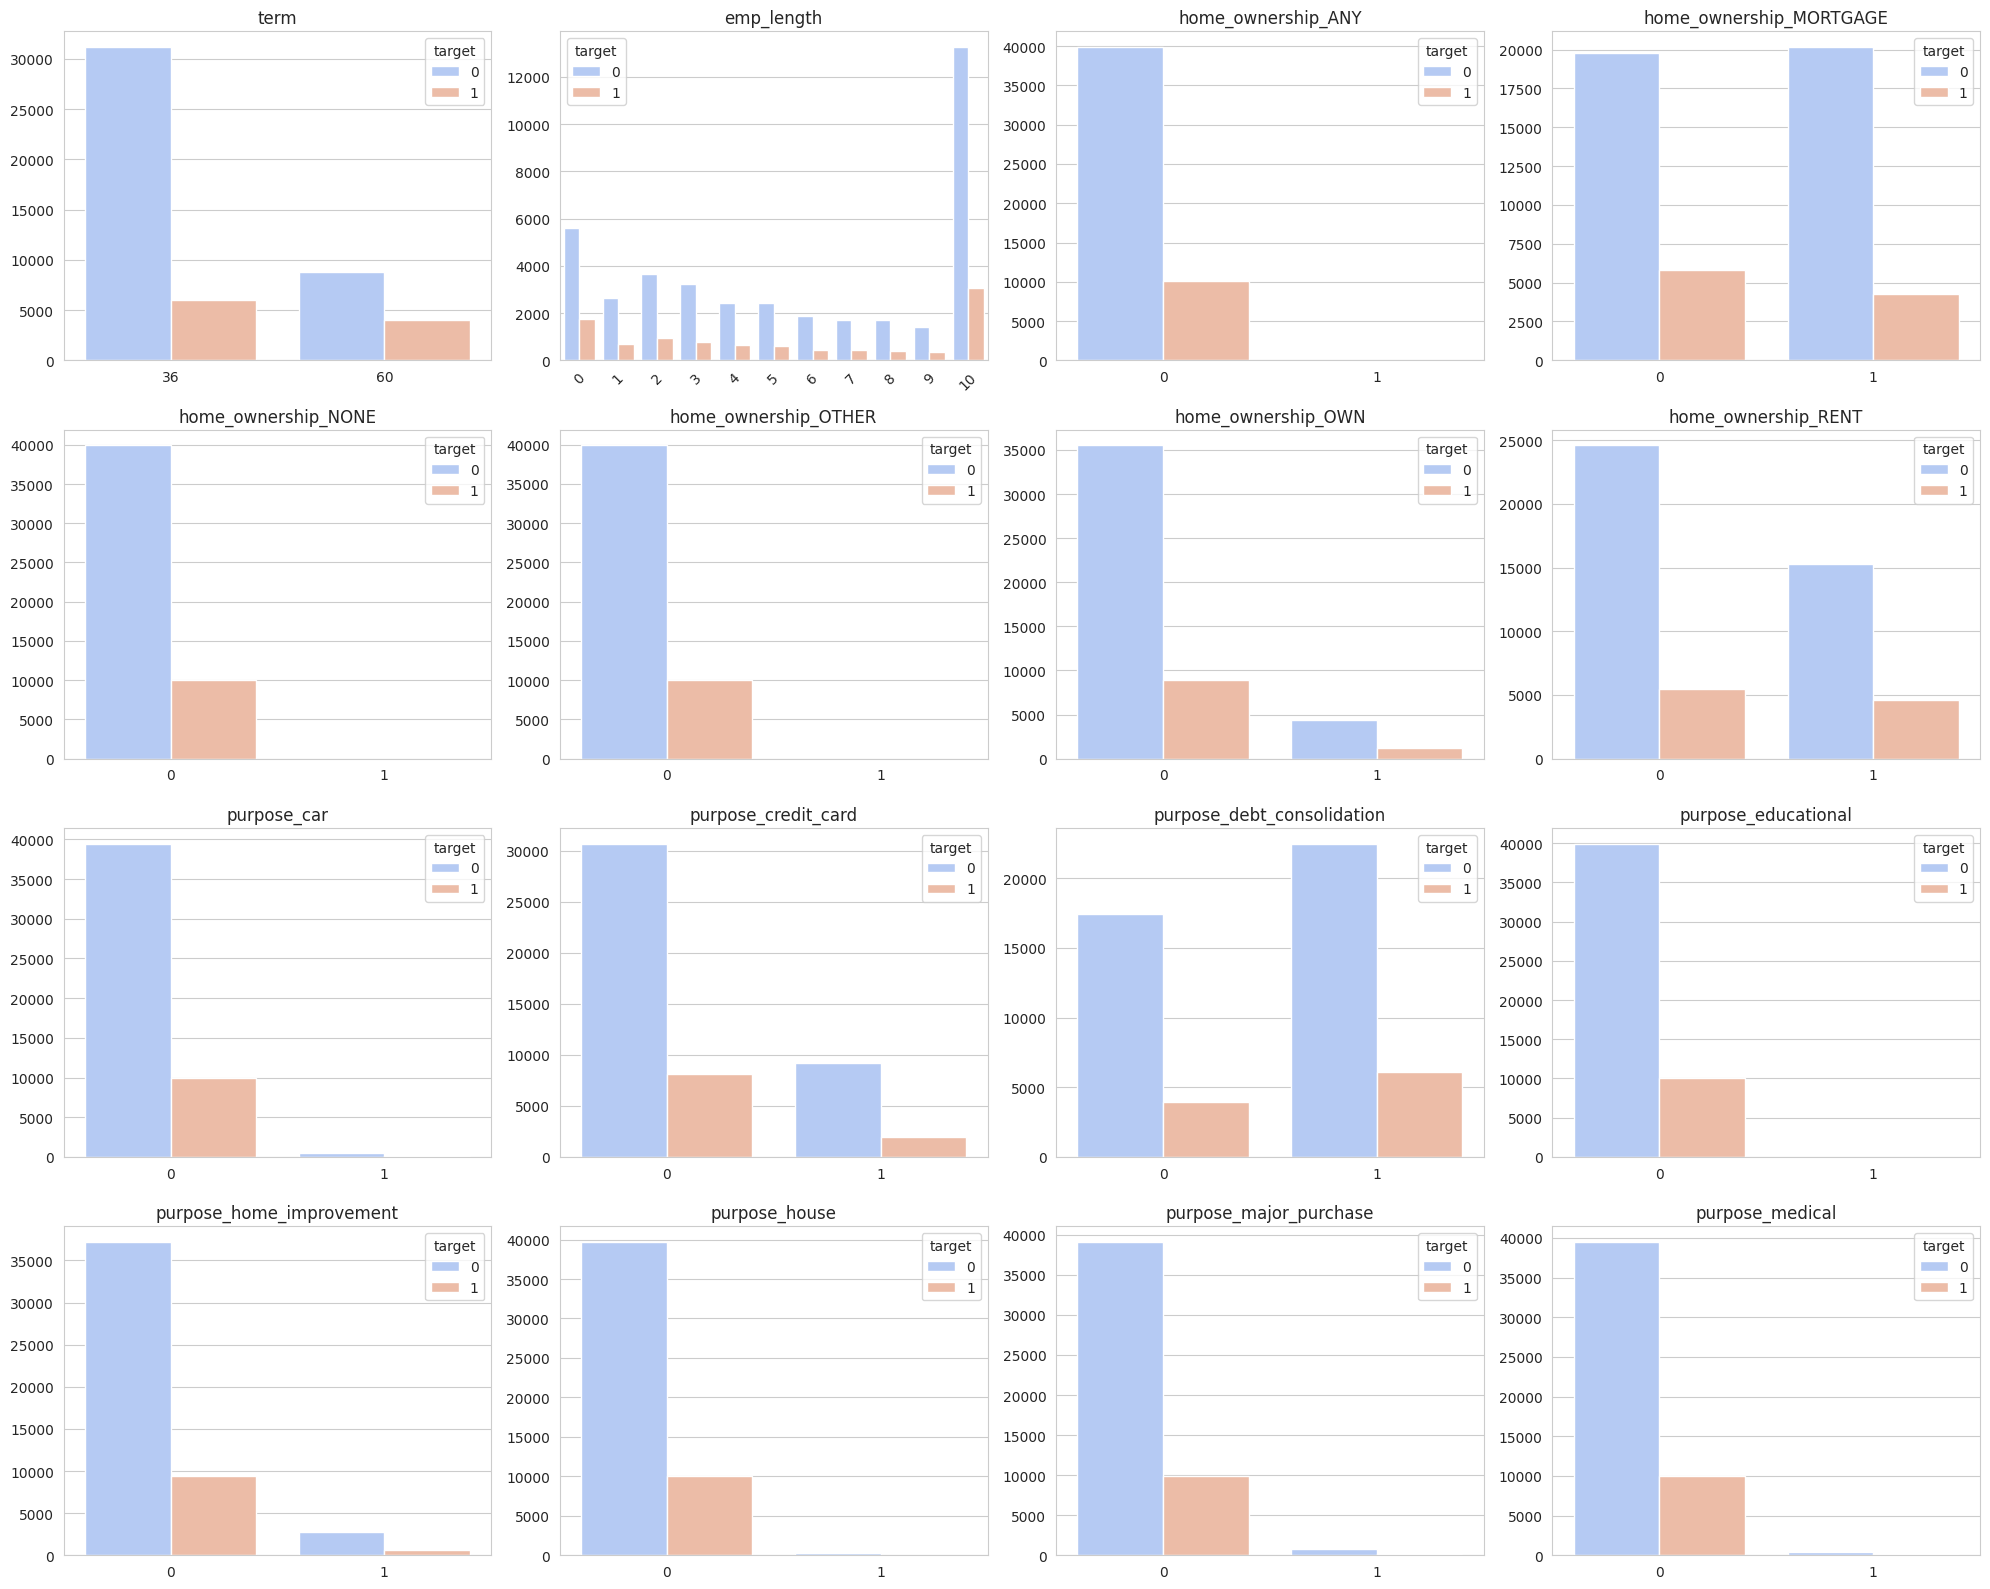

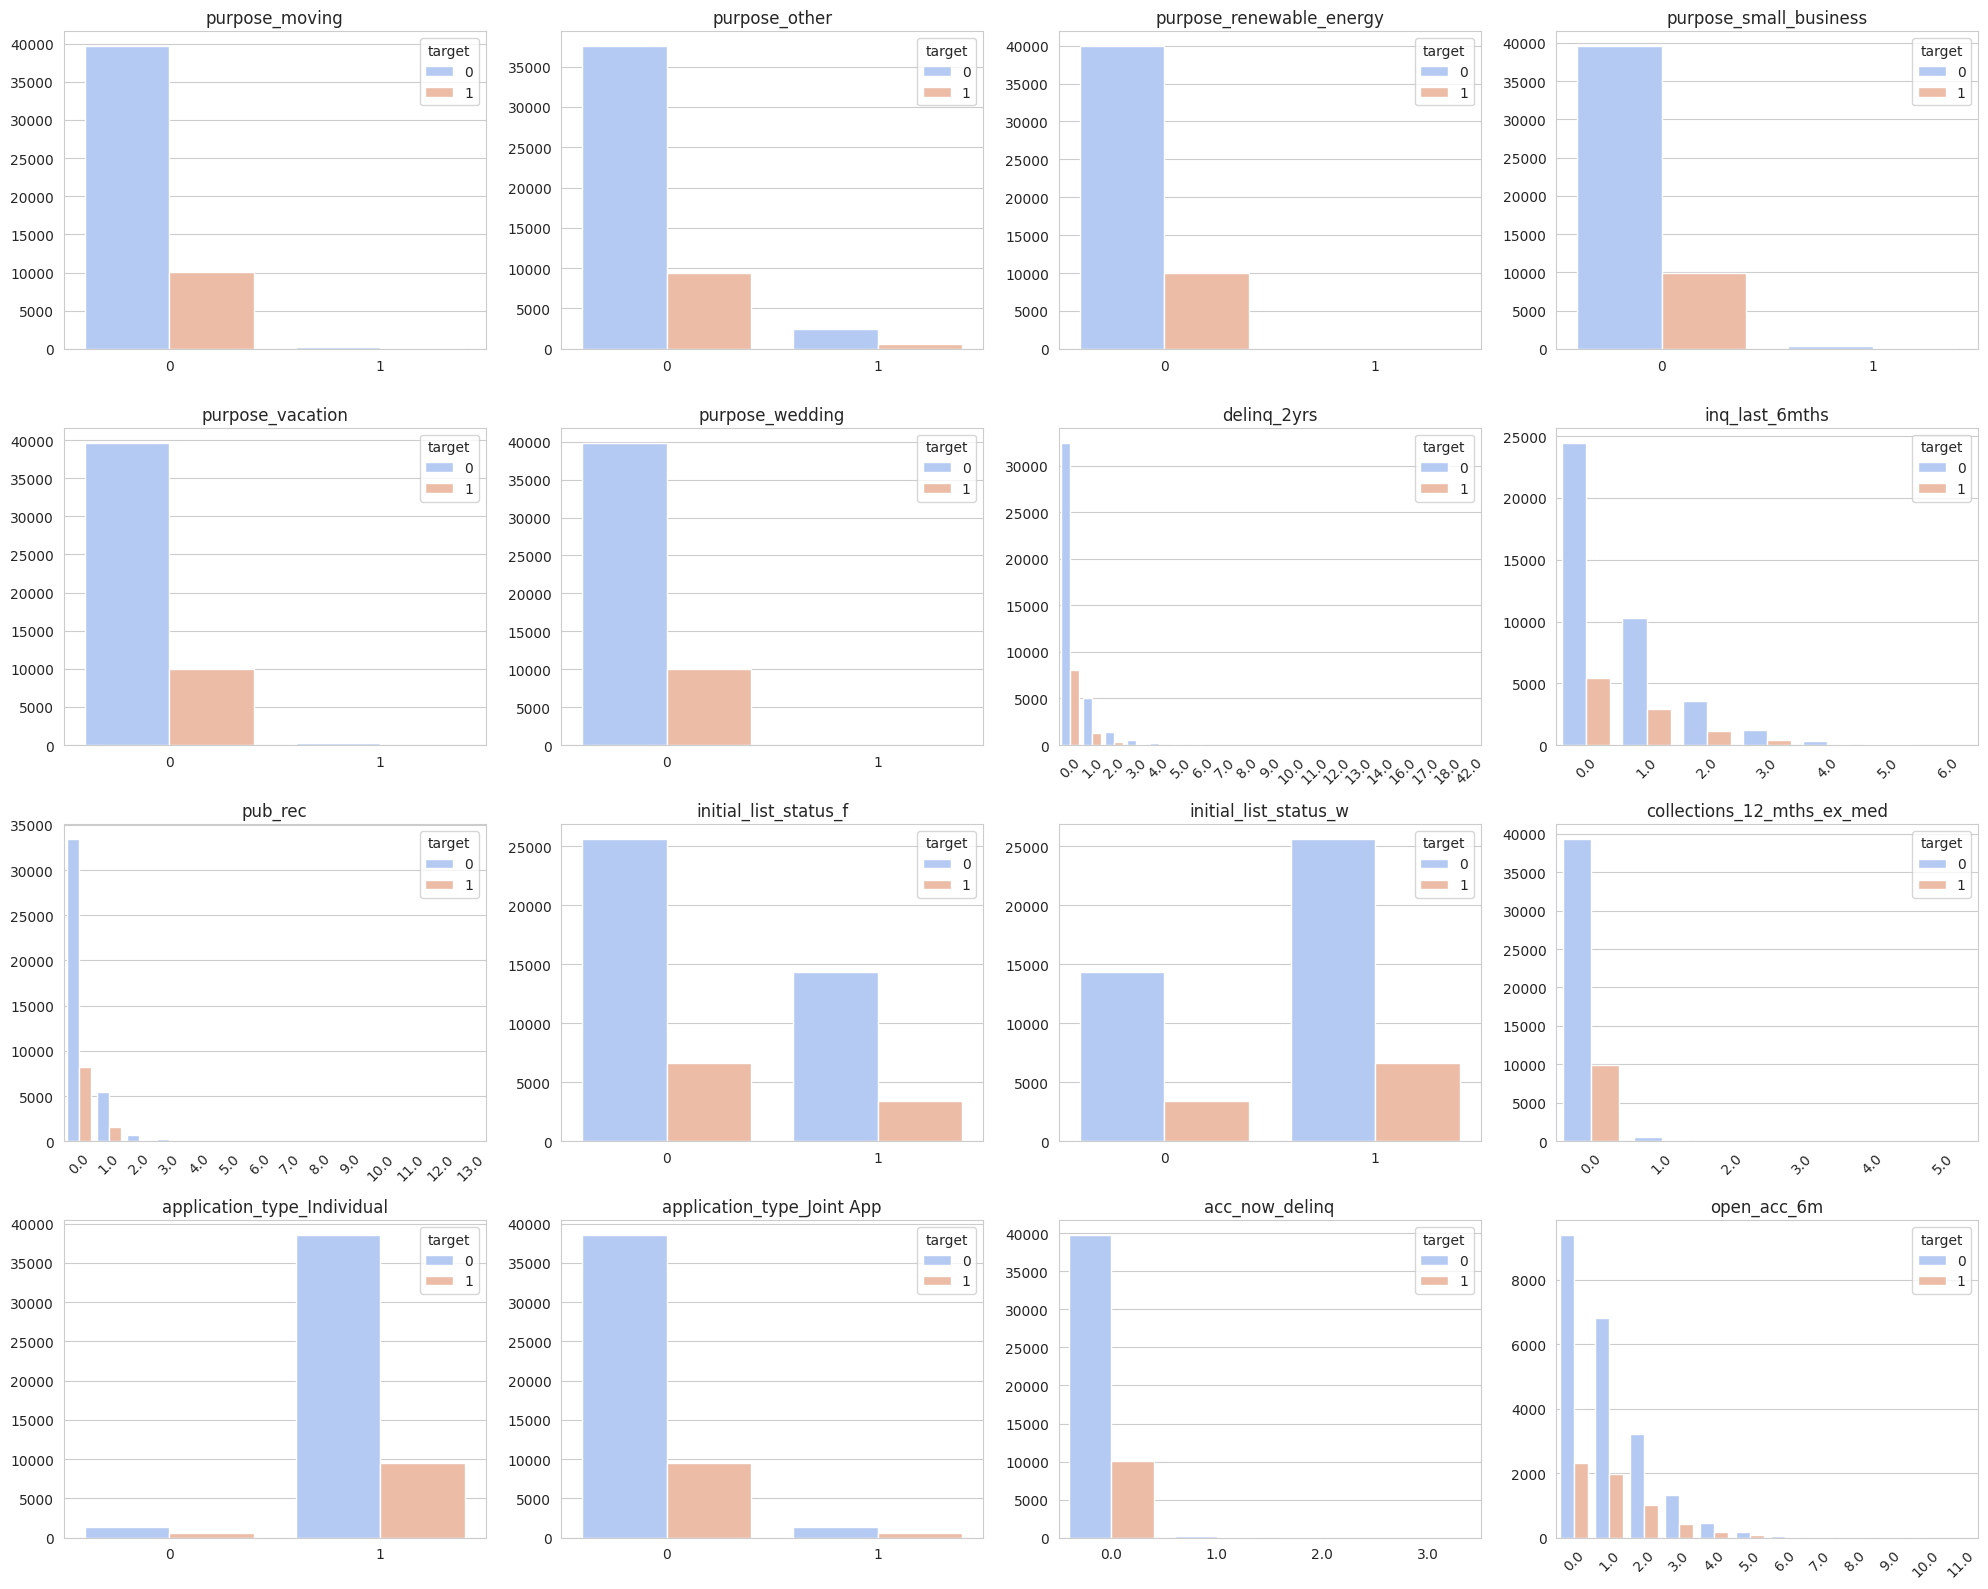

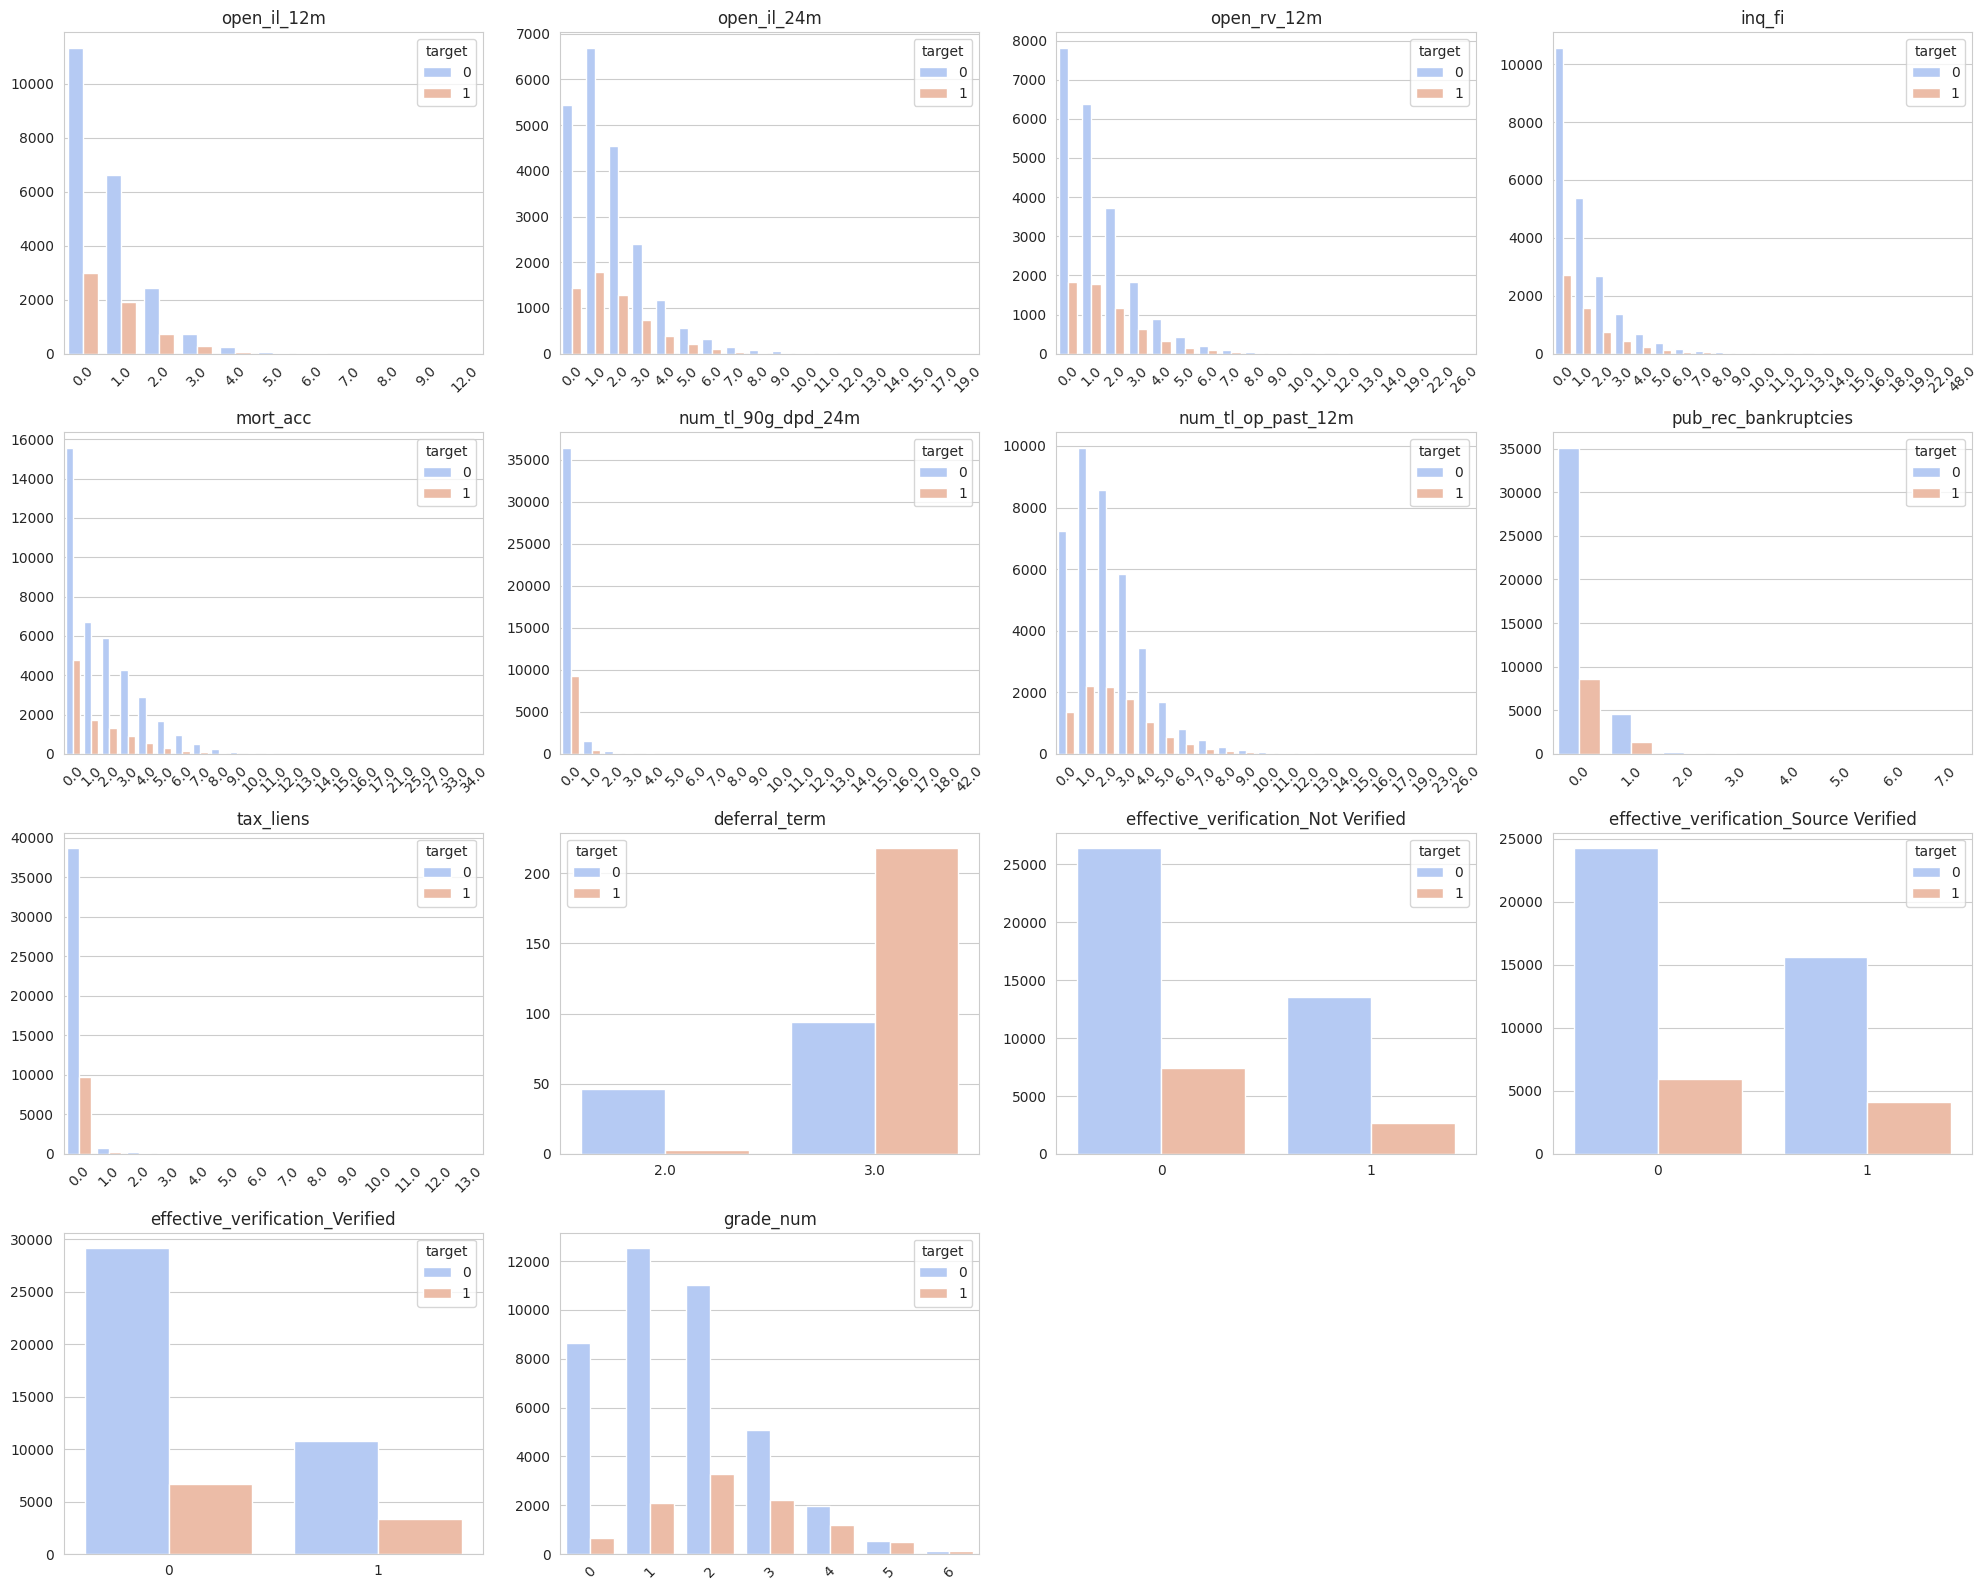


🚀 [NUMERIC] 변수 시각화 시작 (총 4 페이지)


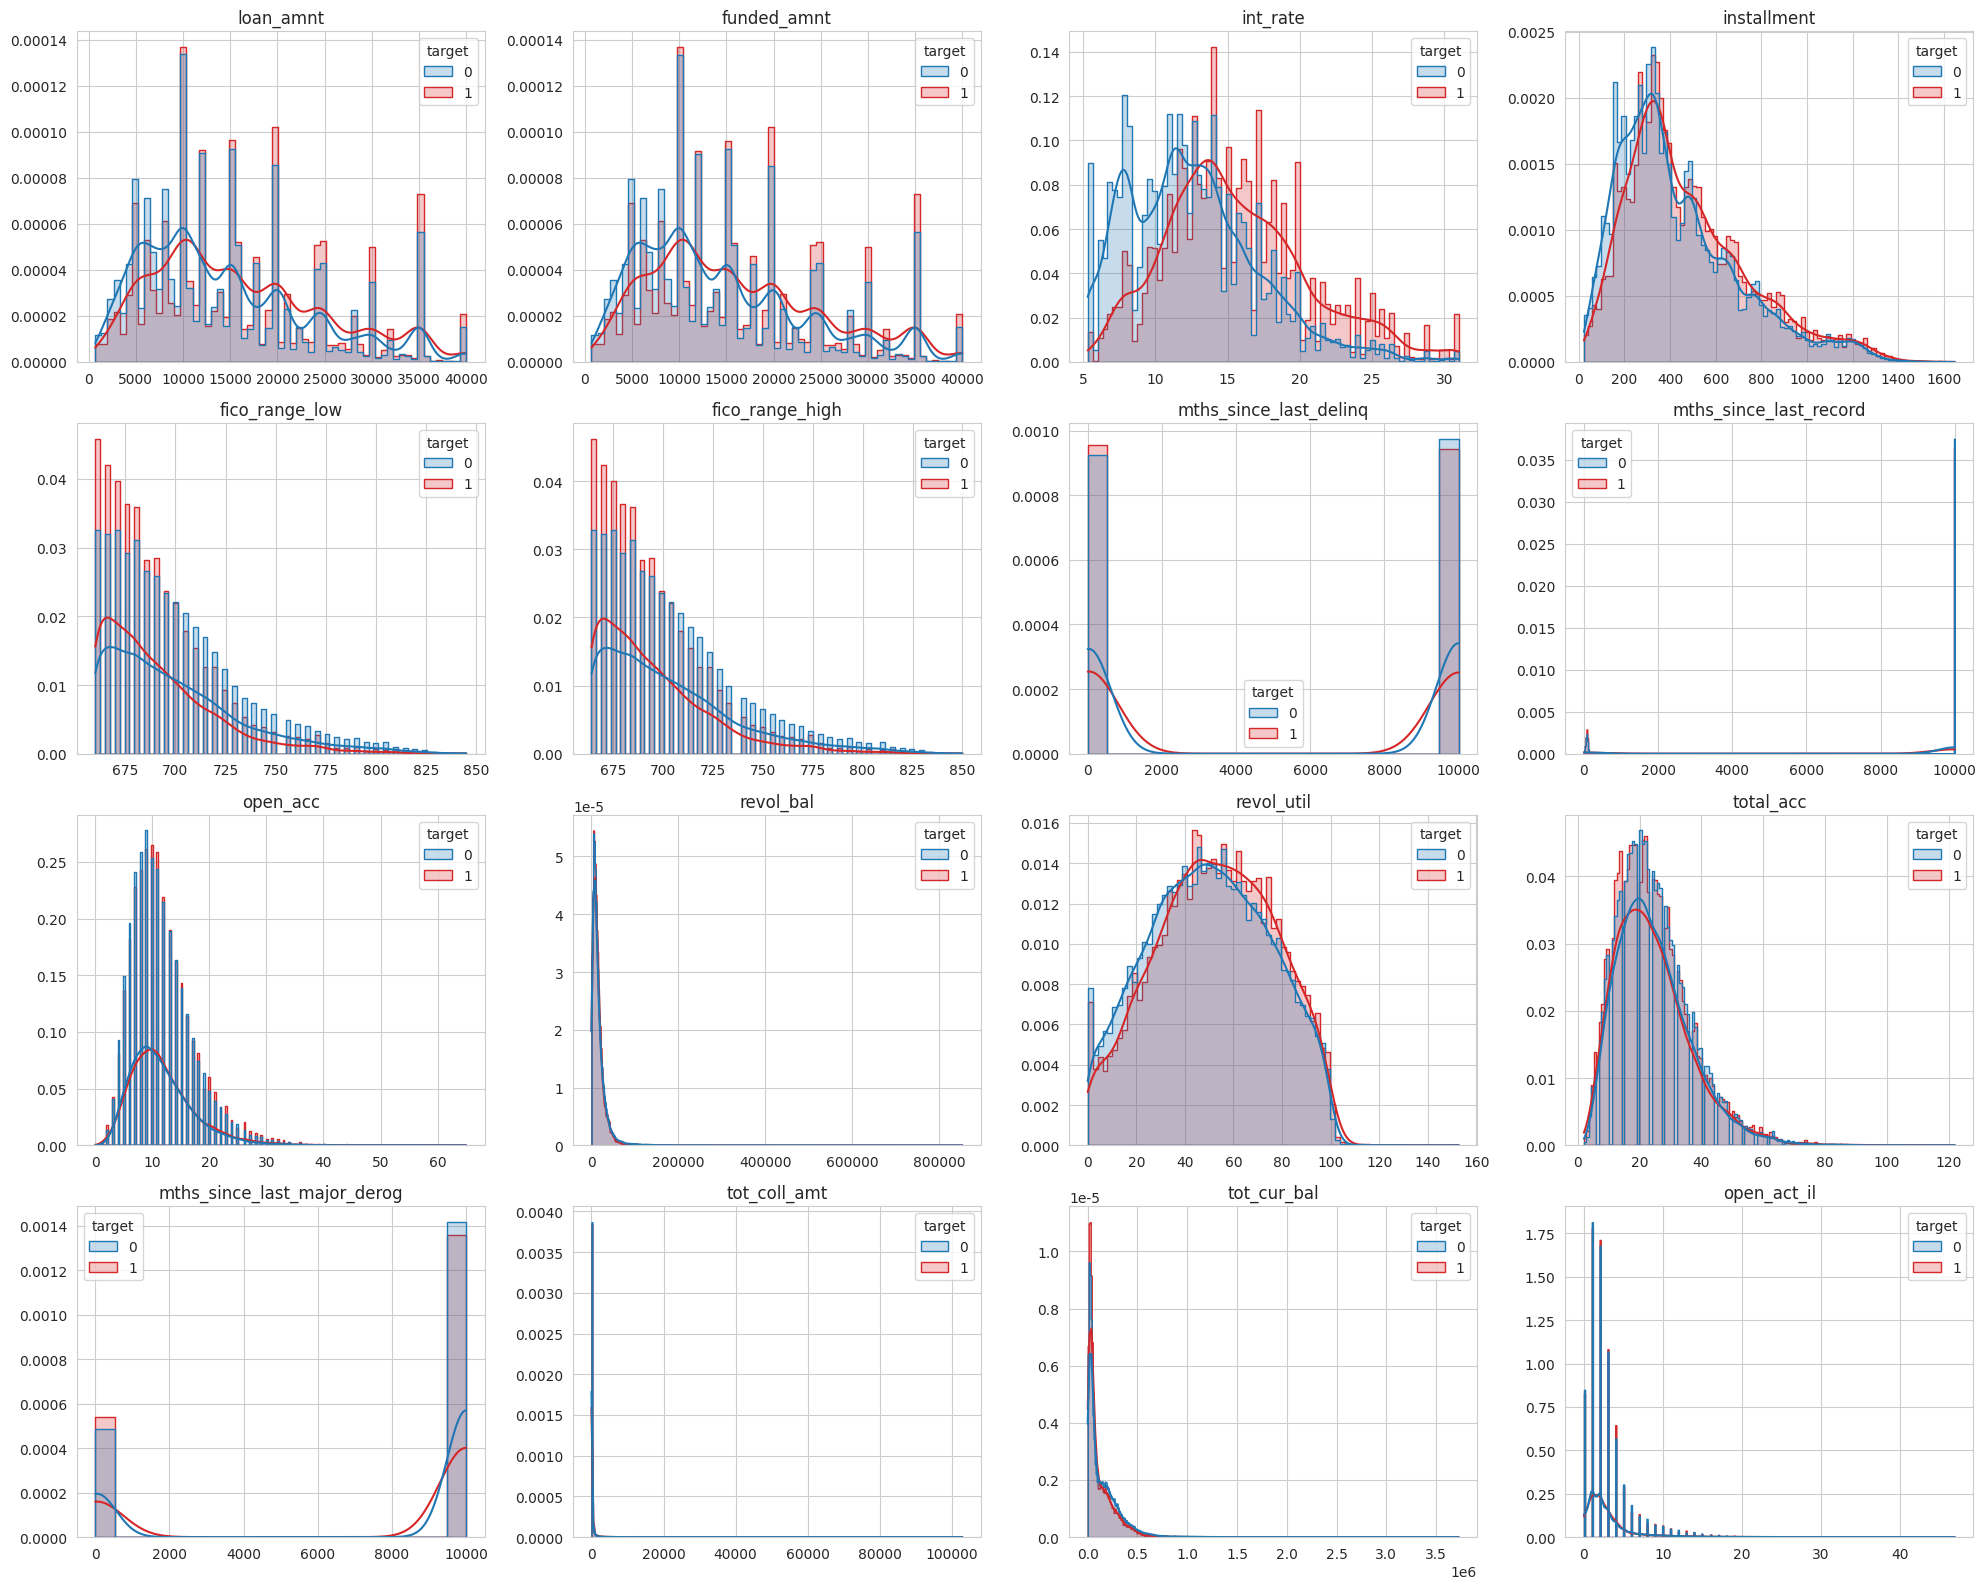

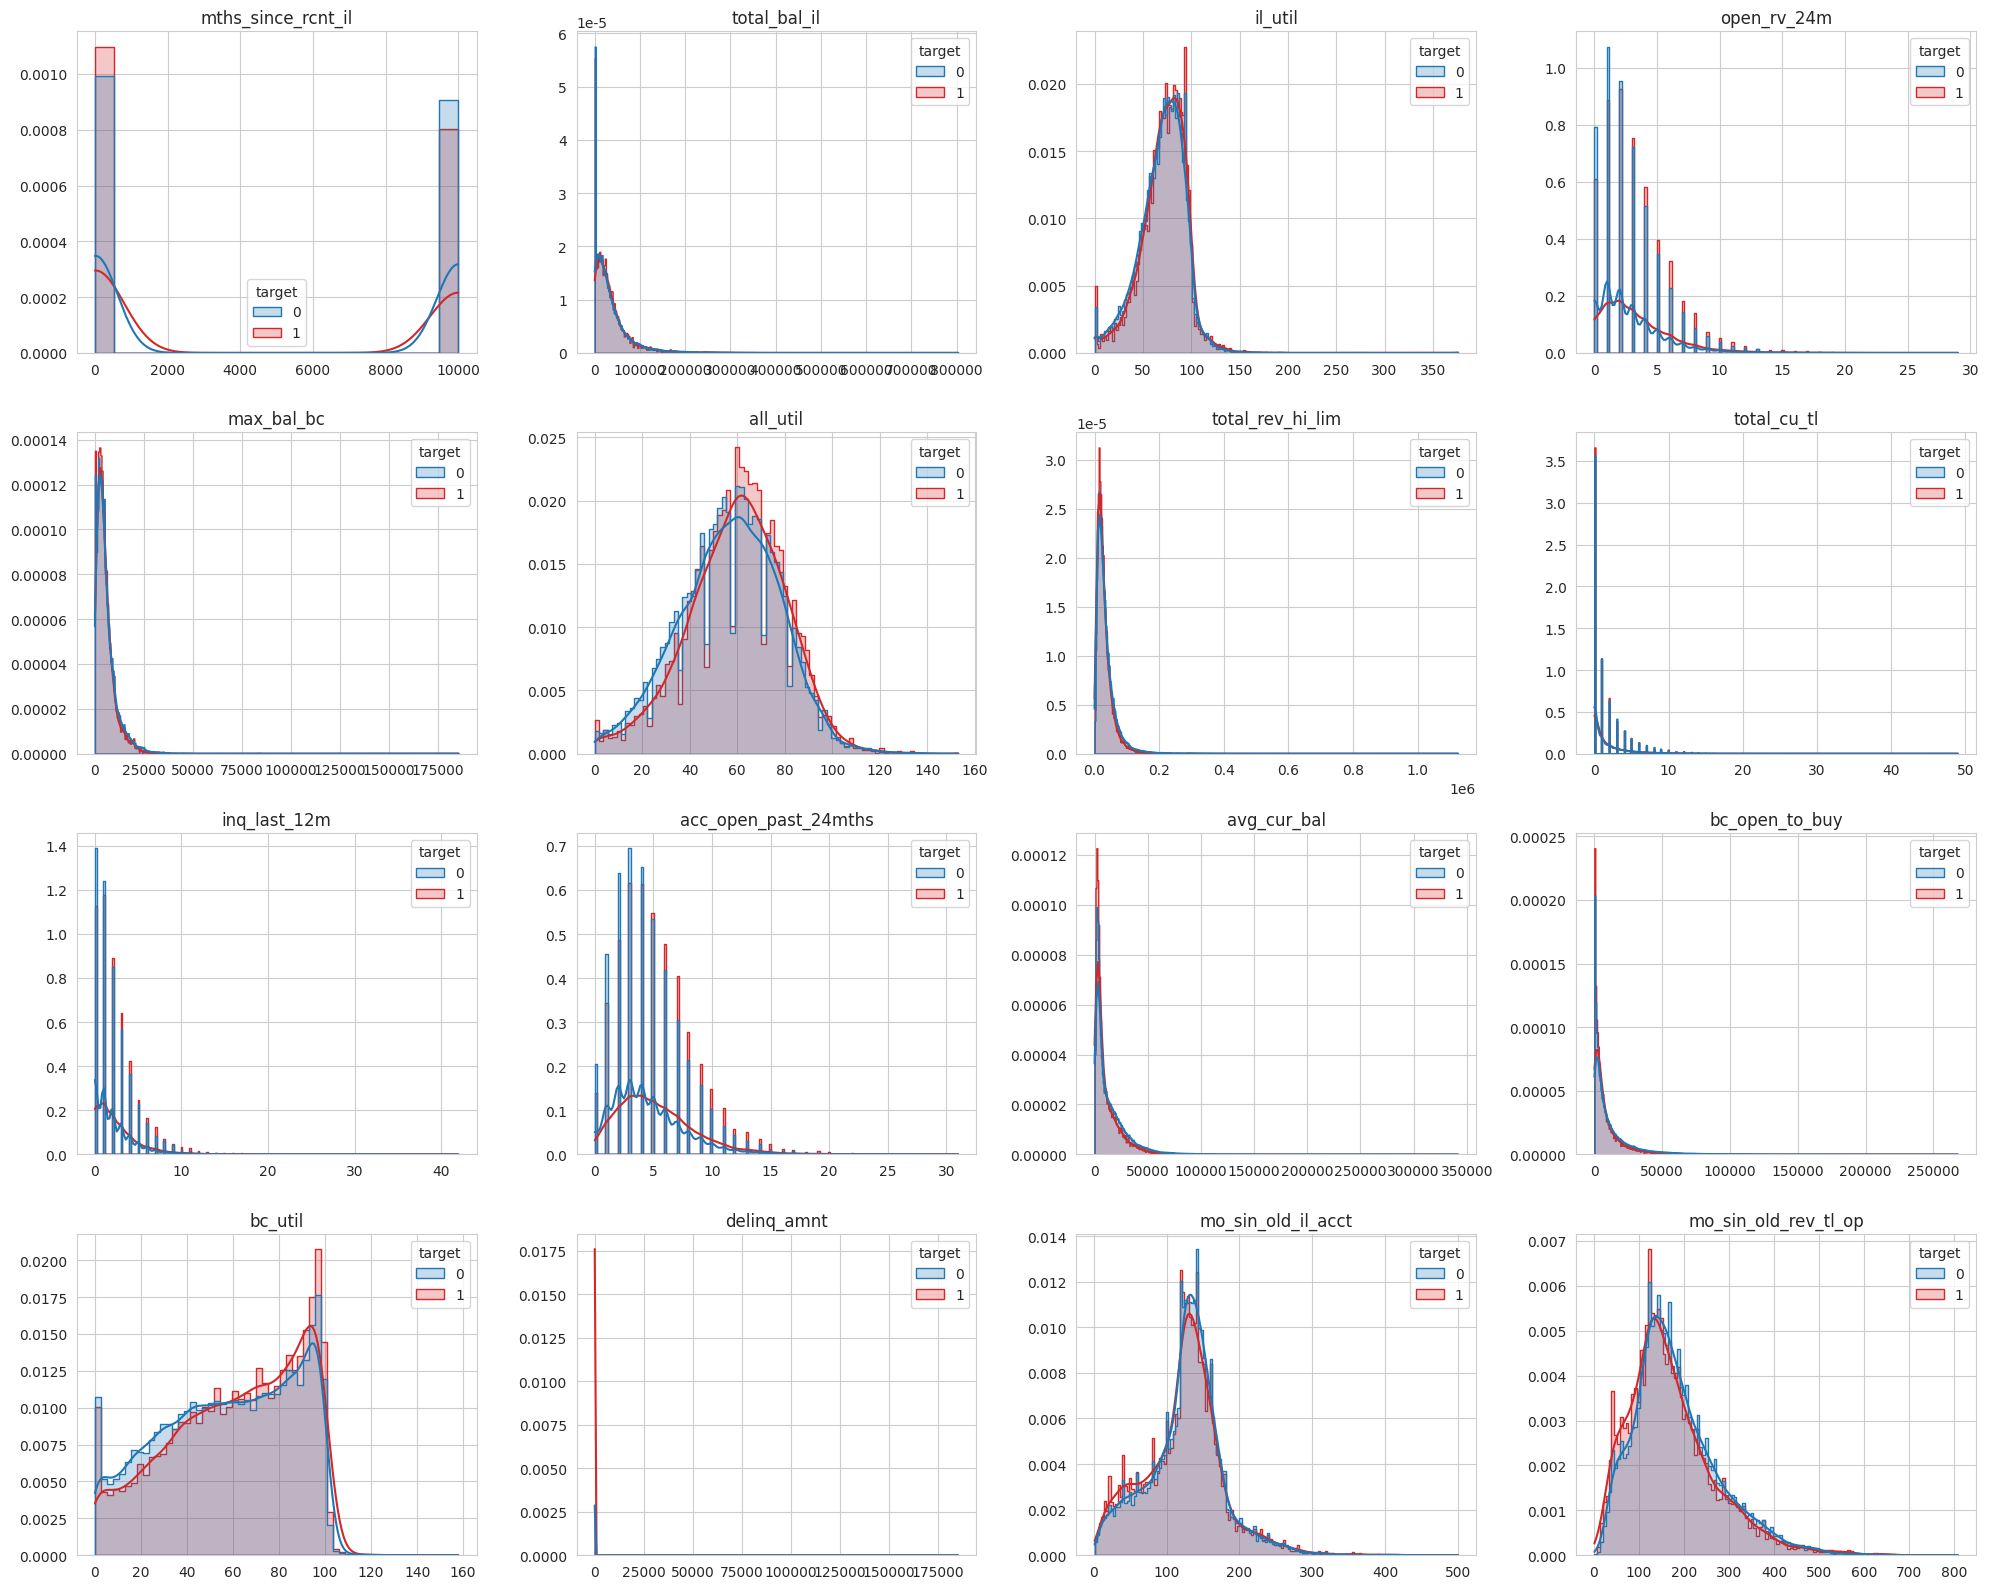

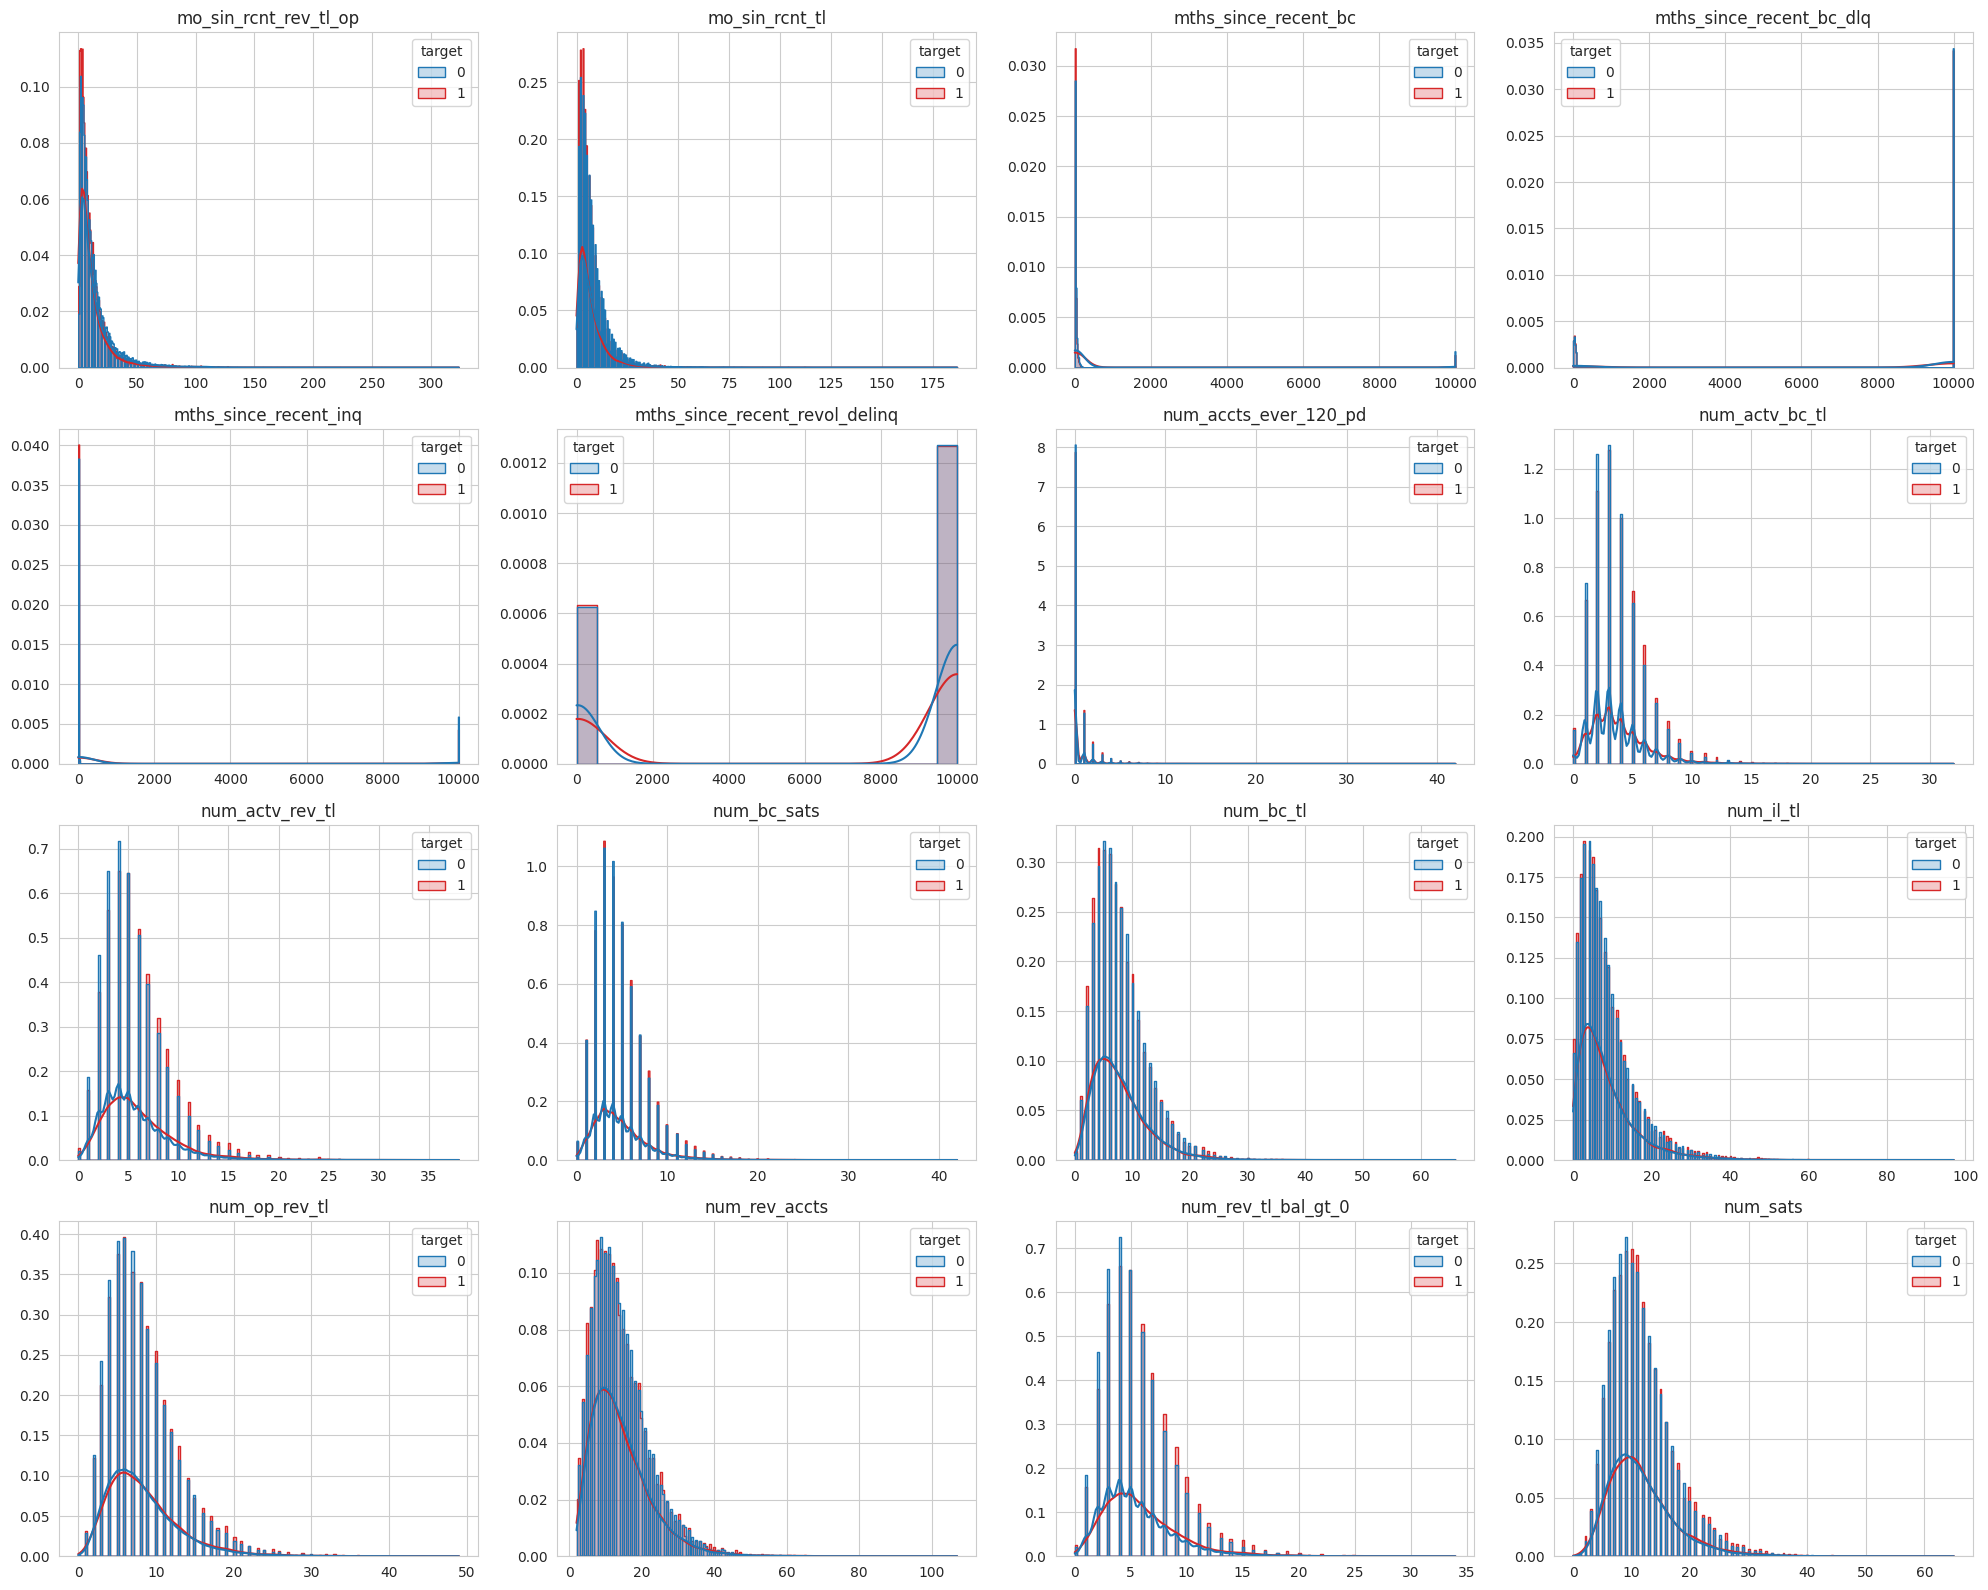

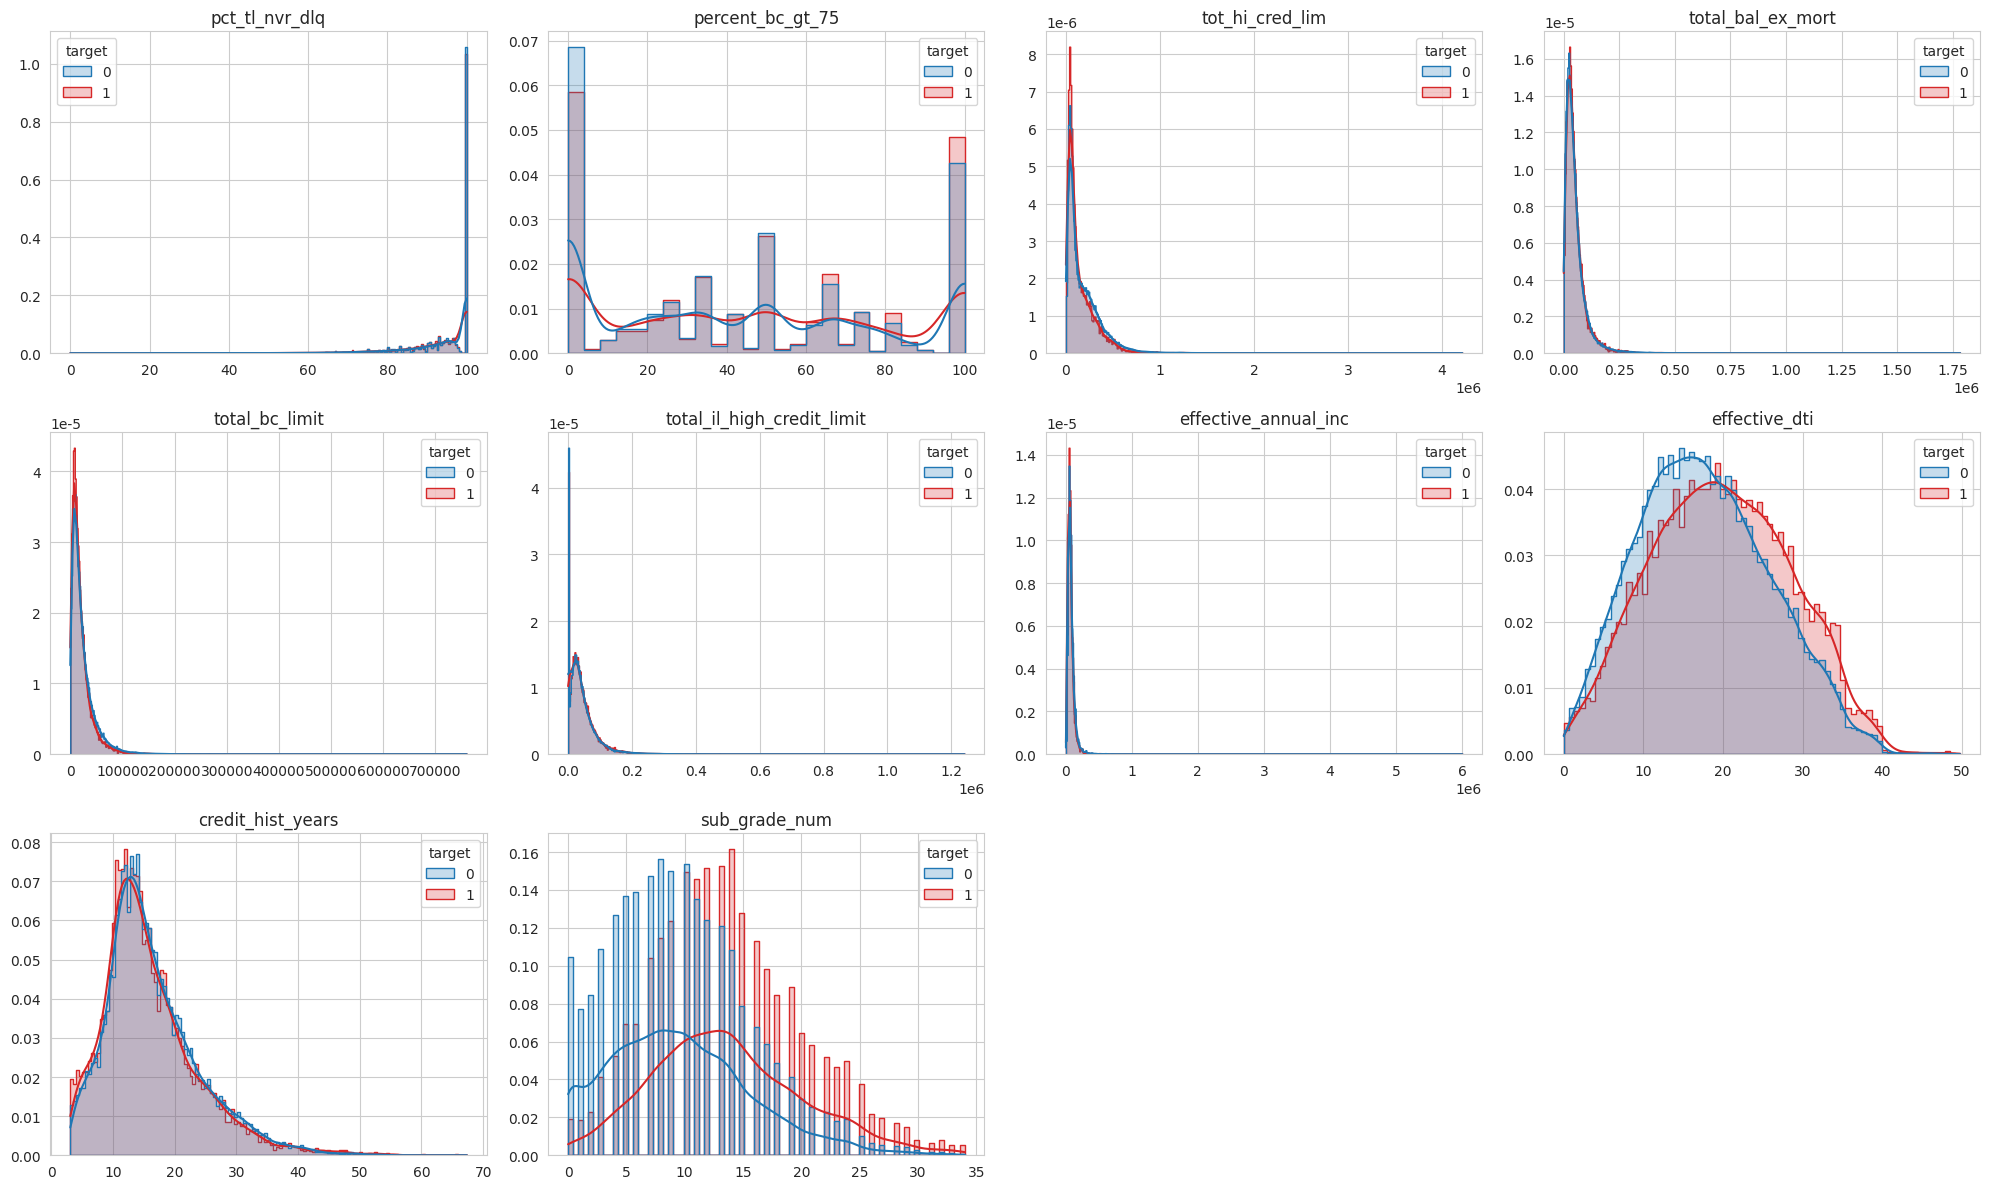

In [29]:
# --- 변수 자동 분류 로직 ---
target_col = 'target'
all_cols = [c for c in df_pd.columns if c != target_col]

# 고유값이 25개 미만이면 범주형(One-Hot 포함), 그 이상이면 연속형으로 간주
cat_cols = [c for c in all_cols if df_pd[c].nunique() < 25]
num_cols = [c for c in all_cols if df_pd[c].nunique() >= 25]

print(f"📊 범주형/이산형 변수: {len(cat_cols)}개")
print(f"📈 연속형/수치형 변수: {len(num_cols)}개")

# --- 시각화 함수 ---
def plot_variables(data, cols, plot_type='numeric', batch_size=16):
    total_vars = len(cols)
    total_pages = math.ceil(total_vars / batch_size)
    
    print(f"\n🚀 [{plot_type.upper()}] 변수 시각화 시작 (총 {total_pages} 페이지)")

    for page in range(total_pages):
        start_idx = page * batch_size
        end_idx = min((page + 1) * batch_size, total_vars)
        current_cols = cols[start_idx:end_idx]
        
        n_cols_grid = 4
        n_rows_grid = math.ceil(len(current_cols) / n_cols_grid)
        
        fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(20, 4 * n_rows_grid))
        axes = axes.flatten() if total_vars > 1 else [axes]
        
        for i, col in enumerate(current_cols):
            ax = axes[i]
            try:
                if data[col].nunique() <= 1: # 값이 하나뿐인 경우 패스
                    continue

                if plot_type == 'categorical':
                    # 범주형: 막대그래프 (부도율 차이 확인)
                    sns.countplot(data=data, x=col, hue='target', ax=ax, palette='coolwarm')
                    ax.set_title(f"{col}")
                    if data[col].nunique() > 5: # 범주가 많으면 x축 글자 회전
                        ax.tick_params(axis='x', rotation=45)
                else:
                    # 연속형: 히스토그램 (분포 겹침 확인)
                    sns.histplot(data=data, x=col, hue='target', kde=True, 
                                 ax=ax, palette={0: '#1f77b4', 1: '#d62728'}, 
                                 element="step", common_norm=False, stat="density")
                    ax.set_title(f"{col}")
            except:
                pass
            
            ax.set_xlabel("")
            ax.set_ylabel("")

        for j in range(i + 1, len(axes)): axes[j].axis('off') # 빈칸 끄기
        plt.tight_layout()
        plt.show()

# --- 실행 ---
# 1. 범주형 변수 그리기 (One-Hot 변수들 확인)
plot_variables(df_pd, cat_cols, plot_type='categorical')

# 2. 연속형 변수 그리기 (금액, 비율 등 확인)
plot_variables(df_pd, num_cols, plot_type='numeric')

🔥 2. [Insight] 상관관계 히트맵 (Correlation Heatmap)
105개 변수를 다 그리면 안 보입니다. Target(부도)과 상관관계가 가장 높은 Top 20 변수만 뽑아서 그리는 것이 핵심입니다.

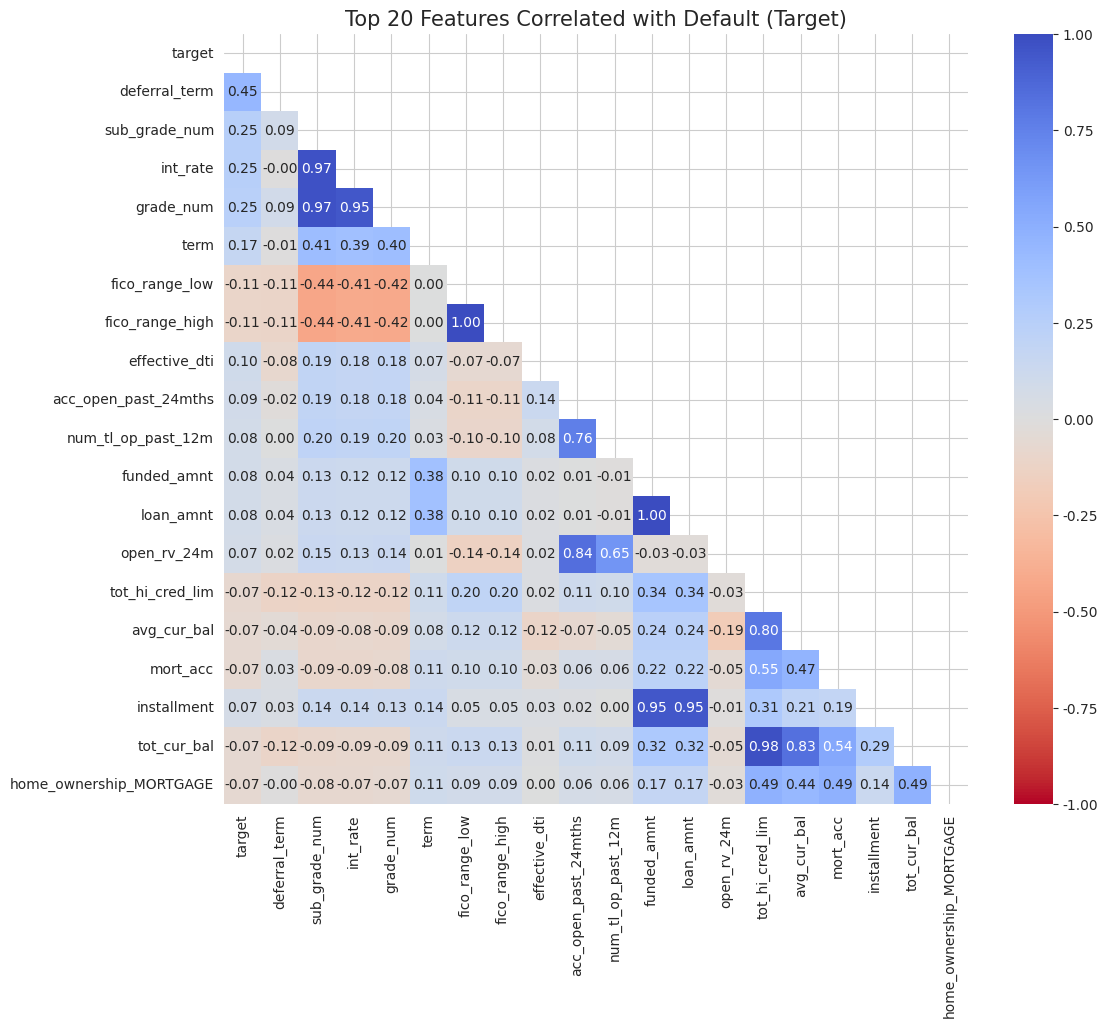

In [30]:
# 상관계수 계산
corr = df_pd.corr()

# Target과 상관관계(절댓값)가 높은 상위 20개 변수 추출
# (0번째는 target 자신이라 제외할 수도 있지만 포함해서 확인)
top_n = 20
top_cols = corr['target'].abs().sort_values(ascending=False).head(top_n).index

plt.figure(figsize=(12, 10))
# 마스크: 대각선 윗부분 가리기
mask = np.triu(np.ones_like(corr.loc[top_cols, top_cols], dtype=bool))

sns.heatmap(df_pd[top_cols].corr(), 
            annot=True, fmt=".2f", cmap='coolwarm_r', # coolwarm_r: 빨강이 양의 상관관계(위험)
            mask=mask, vmin=-1, vmax=1)

plt.title(f'Top {top_n} Features Correlated with Default (Target)', fontsize=15)
plt.show()

📈 3. [Biz Insight] 등급별 리스크 vs 리턴 분석
이 프로젝트의 **"꽃"**입니다. **"이자율(수익)은 높은데 부도율(위험)은 낮은 꿀통 구간"**이 있는지 확인합니다.

In [31]:
# 중간 점검: 데이터가 제대로 들어갔는지 확인
print(df_pd[['grade_num', 'int_rate', 'target']].head())
print("-" * 30)
print(df_pd.groupby('grade_num')['int_rate'].mean())

   grade_num  int_rate  target
0          2     15.22       0
1          0      5.93       0
2          0      8.19       0
3          1      9.16       0
4          2     15.61       0
------------------------------
grade_num
0     7.117907
1    10.709589
2    14.127424
3    18.117630
4    21.583000
5    25.176449
6    28.074291
Name: int_rate, dtype: float32


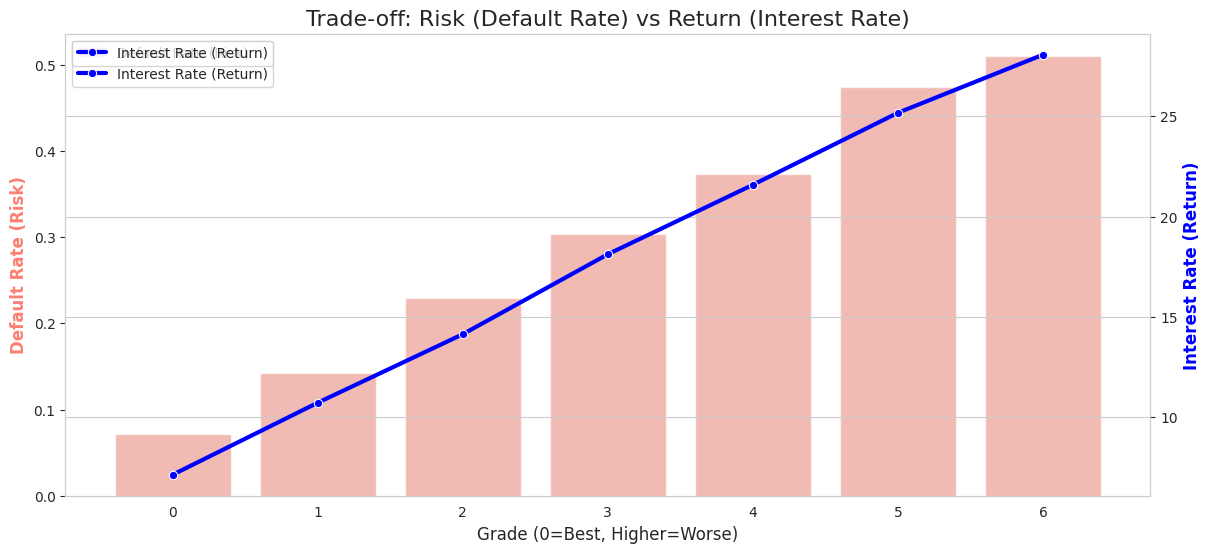

In [32]:
plt.figure(figsize=(14, 6))

# grade_num별 집계 (부도율, 평균 이자율, 대출 건수)
# grade_num이 0(A등급) -> 높을수록(G등급)으로 가정
risk_return = df_pd.groupby('grade_num').agg(
    default_rate=('target', 'mean'),
    int_rate=('int_rate', 'mean'),
    count=('target', 'count')
).reset_index()

# 시각화 (이중축 사용)
ax1 = sns.barplot(data=risk_return, x='grade_num', y='default_rate', 
                  color='salmon', alpha=0.6, label='Default Rate (Risk)')
ax2 = ax1.twinx()
sns.lineplot(data=risk_return, x='grade_num', y='int_rate', 
             color='blue', marker='o', lw=3, ax=ax2, label='Interest Rate (Return)')

# 스타일링
ax1.set_ylabel('Default Rate (Risk)', color='salmon', fontsize=12, fontweight='bold')
ax2.set_ylabel('Interest Rate (Return)', color='blue', fontsize=12, fontweight='bold')
ax1.set_xlabel('Grade (0=Best, Higher=Worse)', fontsize=12)
plt.title('Trade-off: Risk (Default Rate) vs Return (Interest Rate)', fontsize=16)
ax1.grid(False) # 막대 쪽 그리드 끄기 (깔끔하게)

# 범례 표시
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()

📦 4. [Deep Dive] 핵심 변수 Boxplot
중요 변수들이 부도/정상 그룹을 얼마나 잘 나누는지 확인합니다. 특히 우리가 만든 파생변수(effective_dti, credit_hist_years)를 확인해보세요.

/tmp/ipykernel_14133/766600552.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='target', y=col, ax=axes[i], palette='Set2',legend=False)
/tmp/ipykernel_14133/766600552.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='target', y=col, ax=axes[i], palette='Set2',legend=False)
/tmp/ipykernel_14133/766600552.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='target', y=col, ax=axes[i], palette='Set2',legend=False)
/tmp/ipykernel_14133/766600552.py:21: FutureWarning: 

Passing `pal

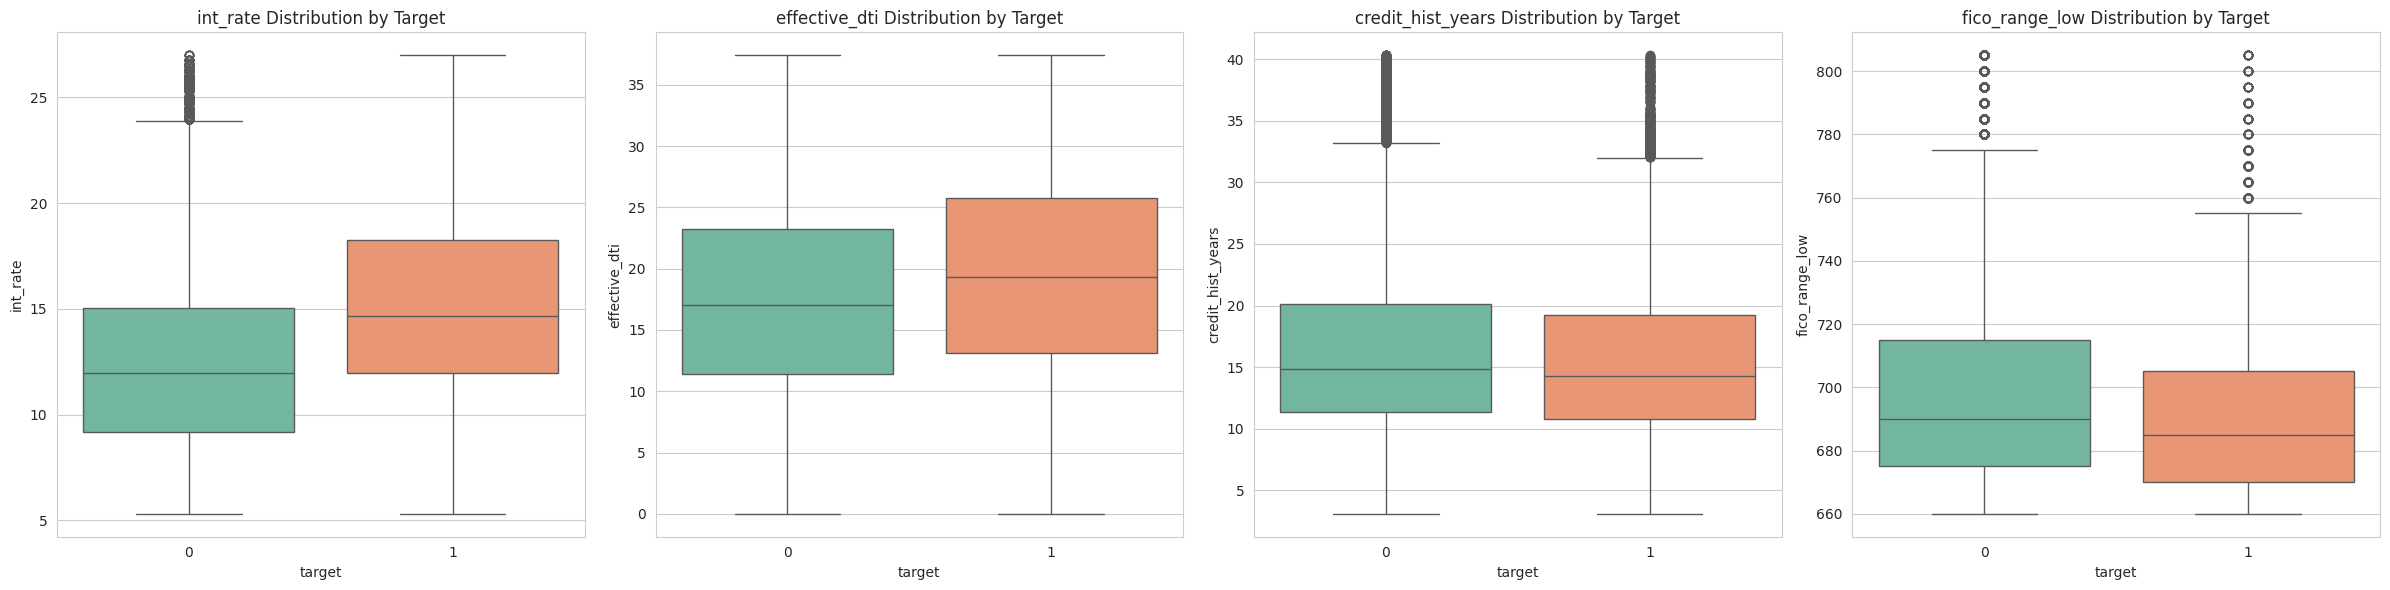

In [33]:
# 확인하고 싶은 핵심 변수들
key_features = [
    'int_rate',               # 이자율 (가장 중요)
    'effective_dti',          # 통합 DTI (상환 능력)
    'credit_hist_years',      # 신용 이력 기간 (경력)
    'fico_range_low'          # 신용 점수 (있다면)
]

# 존재하는 컬럼만 필터링
plot_feats = [c for c in key_features if c in df_pd.columns]

fig, axes = plt.subplots(1, len(plot_feats), figsize=(6 * len(plot_feats), 6))
if len(plot_feats) == 1: axes = [axes]

for i, col in enumerate(plot_feats):
    # 이상치(Outlier) 때문에 박스가 찌그러지는 것을 방지하기 위해 y축 제한을 둘 수 있음
    # 여기서는 상위 99% 값까지만 잘라서 보여줌 (Outlier removal for visualization)
    upper_limit = df_pd[col].quantile(0.99)
    plot_data = df_pd[df_pd[col] <= upper_limit]
    
    sns.boxplot(data=plot_data, x='target', y=col, ax=axes[i], palette='Set2',legend=False)
    axes[i].set_title(f'{col} Distribution by Target')

plt.tight_layout()
plt.show()

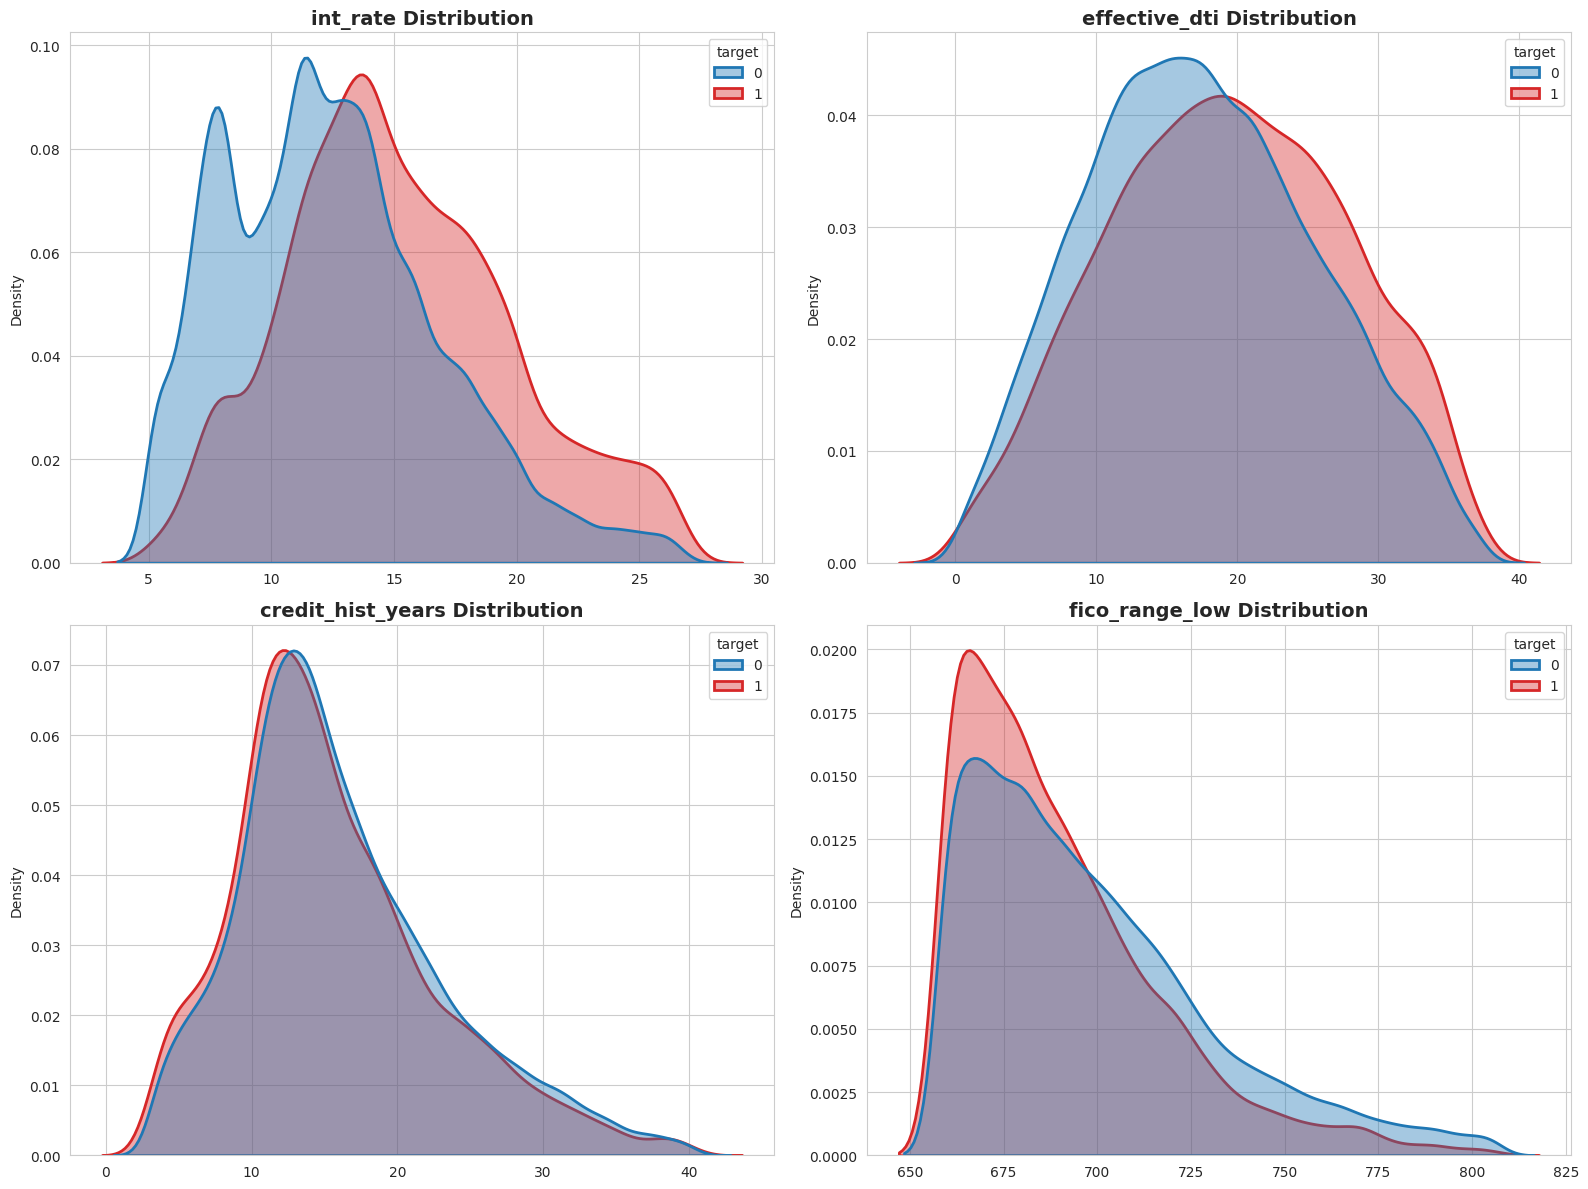

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# 시각화할 변수 리스트
key_features = ['int_rate', 'effective_dti', 'credit_hist_years', 'fico_range_low']
plot_feats = [c for c in key_features if c in df_pd.columns]

# 캔버스 설정
fig, axes = plt.subplots(2, 2, figsize=(16, 12)) # 2x2 격자
axes = axes.flatten()

for i, col in enumerate(plot_feats):
    # 상위 1% 이상치 제거 (그래프 모양 예쁘게 하기 위함)
    upper_limit = df_pd[col].quantile(0.99)
    plot_data = df_pd[df_pd[col] <= upper_limit]
    
    # KDE Plot 그리기
    # common_norm=False: 두 그룹의 데이터 개수가 달라도 높이를 맞춰서 비교하기 쉽게 함
    sns.kdeplot(data=plot_data, x=col, hue='target', 
                fill=True, alpha=0.4, linewidth=2,
                palette={0: '#1f77b4', 1: '#d62728'}, # 파랑(정상), 빨강(부도)
                common_norm=False, ax=axes[i])
    
    axes[i].set_title(f'{col} Distribution', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Density')

plt.tight_layout()
plt.show()

💡 5. [Bonus] 공동 대출(Joint App) 효과 확인
우리가 열심히 만든 application_type 변수가 실제로 의미가 있는지 확인해 봅니다. (application_type이 One-Hot Encoding 되어 application_type_Joint App 등의 이름으로 존재할 것입니다.)

분석 대상 컬럼: application_type_Joint App


/tmp/ipykernel_14133/3569525910.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_pd, x=target_joint_col, y='target', palette='viridis')


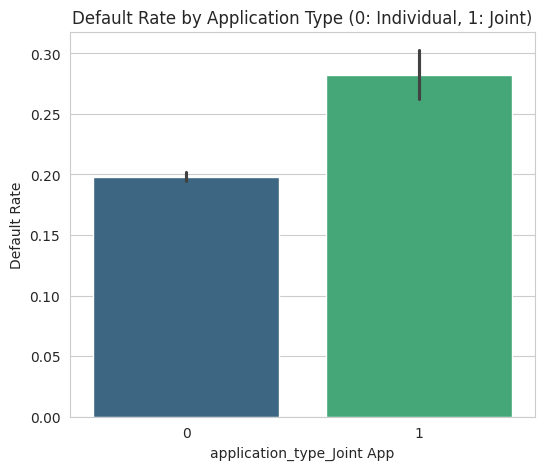

In [37]:
# 컬럼 이름 찾기 (One-Hot이라 이름이 다를 수 있음)
joint_col = [c for c in df_pd.columns if 'Joint' in c or 'joint' in c]

if joint_col:
    target_joint_col = joint_col[0] # 보통 application_type_Joint App
    print(f"분석 대상 컬럼: {target_joint_col}")

    plt.figure(figsize=(6, 5))
    sns.barplot(data=df_pd, x=target_joint_col, y='target', palette='viridis')
    plt.title('Default Rate by Application Type (0: Individual, 1: Joint)')
    plt.ylabel('Default Rate')
    plt.show()
else:
    print("Joint App 관련 컬럼을 찾을 수 없습니다.")

변수 중요도(Feature Importance)는 **"어떤 변수가 부도(Target)를 예측하는 데 가장 큰 영향을 미치는가?"**를 보여주는 가장 중요한 시각화 중 하나입니다.

빠르고 직관적인 결과를 위해 Random Forest 모델을 사용하여 중요도를 추출하고, 상위 30개를 시각화하는 코드를 작성해 드립니다.

전체 데이터 Shape: (1125996, 105)
------------------------------
모델 학습용 데이터: (100000, 104)
Random Forest 모델 학습 중... (잠시만 기다려주세요)


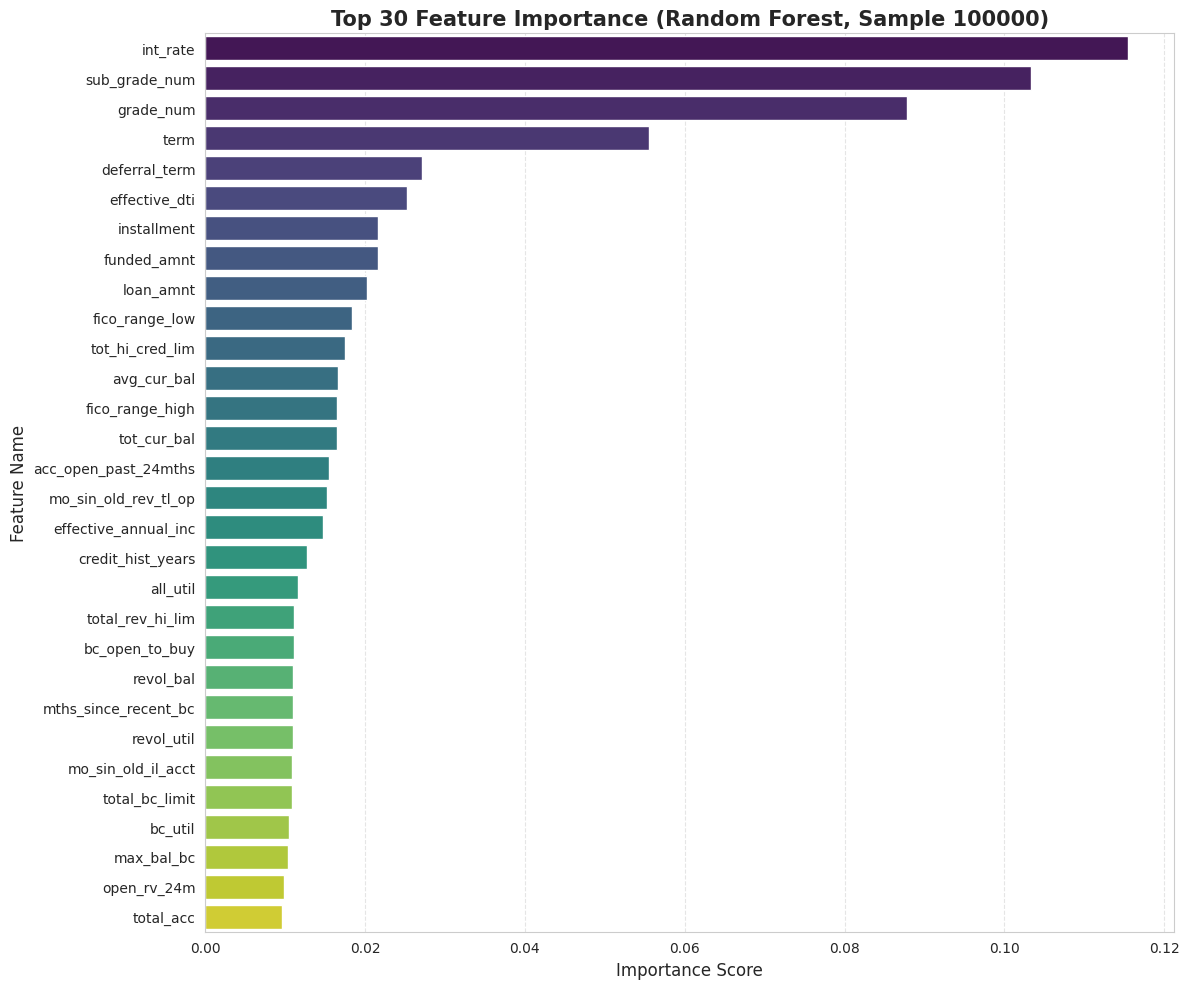


[Top 10 핵심 변수]
       Feature  Importance
      int_rate    0.115478
 sub_grade_num    0.103372
     grade_num    0.087803
          term    0.055484
 deferral_term    0.027130
 effective_dti    0.025284
   installment    0.021619
   funded_amnt    0.021583
     loan_amnt    0.020178
fico_range_low    0.018374


In [38]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# 한글 폰트 설정 (필요시)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

# ---------------------------------------------------------
# 1. 데이터 로드 및 준비
# ---------------------------------------------------------
file_path = '../data/processed/train_final.parquet'
df = pl.read_parquet(file_path)

print(f"전체 데이터 Shape: {df.shape}")

# 🚨 중요: 속도를 위해 샘플링 (전체 데이터로 돌리면 오래 걸림)
# 10만 개 정도면 변수 중요도 경향을 파악하기에 충분합니다.
n_sample = 100000
df_sample = df.sample(n=n_sample, seed=42).to_pandas()

# X(독립변수)와 y(종속변수) 분리
X = df_sample.drop(columns=['target'])
y = df_sample['target']

# 혹시 모를 결측치 안전장치 (0으로 채움)
X = X.fillna(0)

print("-" * 30)
print(f"모델 학습용 데이터: {X.shape}")
print("Random Forest 모델 학습 중... (잠시만 기다려주세요)")

# ---------------------------------------------------------
# 2. Random Forest 모델 학습
# ---------------------------------------------------------
# n_estimators=100 (나무 100개), max_depth=10 (너무 깊지 않게)
rf = RandomForestClassifier(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42)
rf.fit(X, y)

# ---------------------------------------------------------
# 3. 중요도 추출 및 정렬
# ---------------------------------------------------------
# 중요도 데이터프레임 생성
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

# 중요도 순으로 내림차순 정렬 후 Top 30 추출
top_30_features = importance_df.sort_values(by='Importance', ascending=False).head(30)

# ---------------------------------------------------------
# 4. 시각화 (Bar Plot)
# ---------------------------------------------------------
plt.figure(figsize=(12, 10))

# 멋진 색상 팔레트 적용
sns.barplot(data=top_30_features, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)

plt.title(f'Top 30 Feature Importance (Random Forest, Sample {n_sample})', fontsize=15, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

# (선택) 텍스트로도 출력
print("\n[Top 10 핵심 변수]")
print(top_30_features[['Feature', 'Importance']].head(10).to_string(index=False))